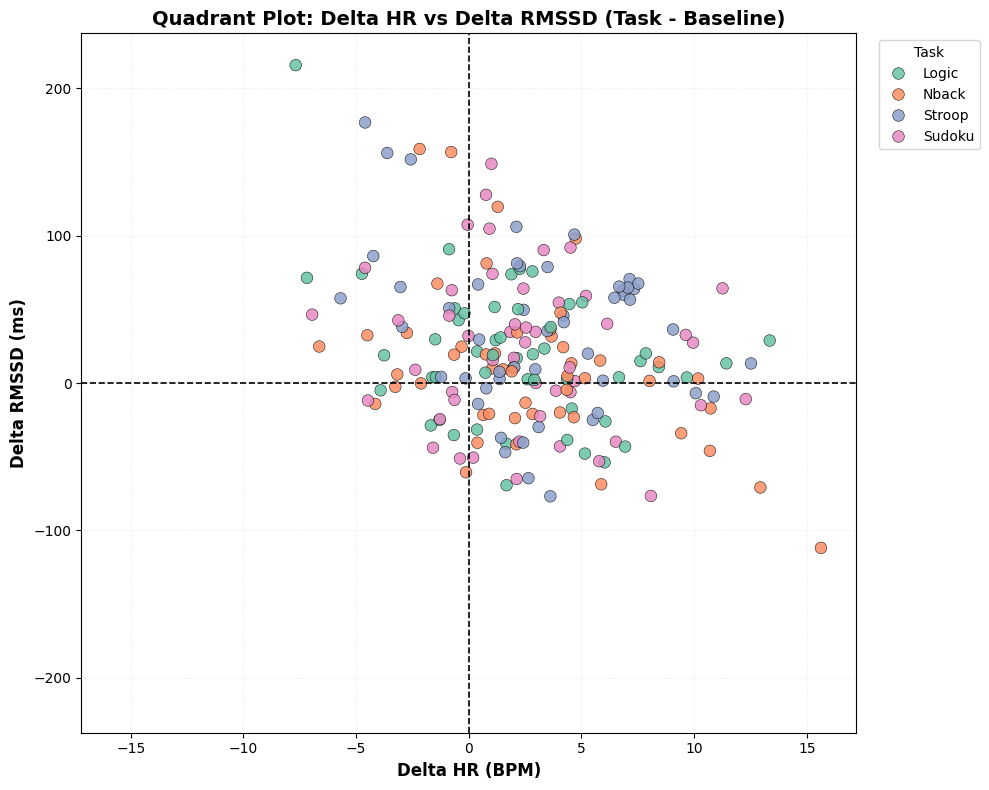

사용 파일: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Only_BVP/Delta_HR_outputs/delta_all_subjects.csv
총 포인트 수: 200
       Delta_HR  Delta_RMSSD
count   200.000      200.000
mean      2.664       21.255
std       4.273       51.615
min      -7.678     -111.865
25%      -0.065      -12.247
50%       2.255       16.272
75%       5.067       51.008
max      15.629      215.745


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Delta_HR.ipynb에서 저장된 전체 Delta 결과 파일 (가능 경로 순서대로 탐색)
candidate_paths = [
    Path('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/Only_BVP/Delta_HR_outputs/delta_all_subjects.csv'),
    Path('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs/delta_all_subjects.csv'),
]

DELTA_CSV = next((p for p in candidate_paths if p.exists()), None)
if DELTA_CSV is None:
    raise FileNotFoundError(
        'delta_all_subjects.csv 파일을 찾지 못했습니다.\n'
        '- /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Only_BVP/Delta_HR_outputs/\n'
        '- /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs/\n'
        '경로를 확인해 주세요.'
    )

delta_df = pd.read_csv(DELTA_CSV)
required_cols = {'Subject', 'Task', 'Delta_HR', 'Delta_RMSSD'}
missing = required_cols - set(delta_df.columns)
if missing:
    raise ValueError(f'필수 컬럼 누락: {missing}')

plot_df = delta_df.dropna(subset=['Delta_HR', 'Delta_RMSSD']).copy()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df,
    x='Delta_HR',
    y='Delta_RMSSD',
    hue='Task',
    palette='Set2',
    alpha=0.85,
    s=70,
    edgecolor='black',
    linewidth=0.4,
)

# 사분면 기준선 (Task - Baseline에서 0이 변화 없음)
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.axhline(0, color='black', linestyle='--', linewidth=1.2)

# 영점(0,0)이 플롯 정중앙에 오도록 축 범위를 0 기준 대칭으로 설정
x_abs = max(abs(plot_df['Delta_HR'].min()), abs(plot_df['Delta_HR'].max()))
y_abs = max(abs(plot_df['Delta_RMSSD'].min()), abs(plot_df['Delta_RMSSD'].max()))
plt.xlim(-x_abs * 1.1, x_abs * 1.1)
plt.ylim(-y_abs * 1.1, y_abs * 1.1)

plt.title('Quadrant Plot: Delta HR vs Delta RMSSD (Task - Baseline)', fontsize=14, fontweight='bold')
plt.xlabel('Delta HR (BPM)', fontsize=12, fontweight='bold')
plt.ylabel('Delta RMSSD (ms)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.25, linestyle=':')
plt.legend(title='Task', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f'사용 파일: {DELTA_CSV}')
print(f'총 포인트 수: {len(plot_df)}')
print(plot_df[['Delta_HR', 'Delta_RMSSD']].describe().round(3))

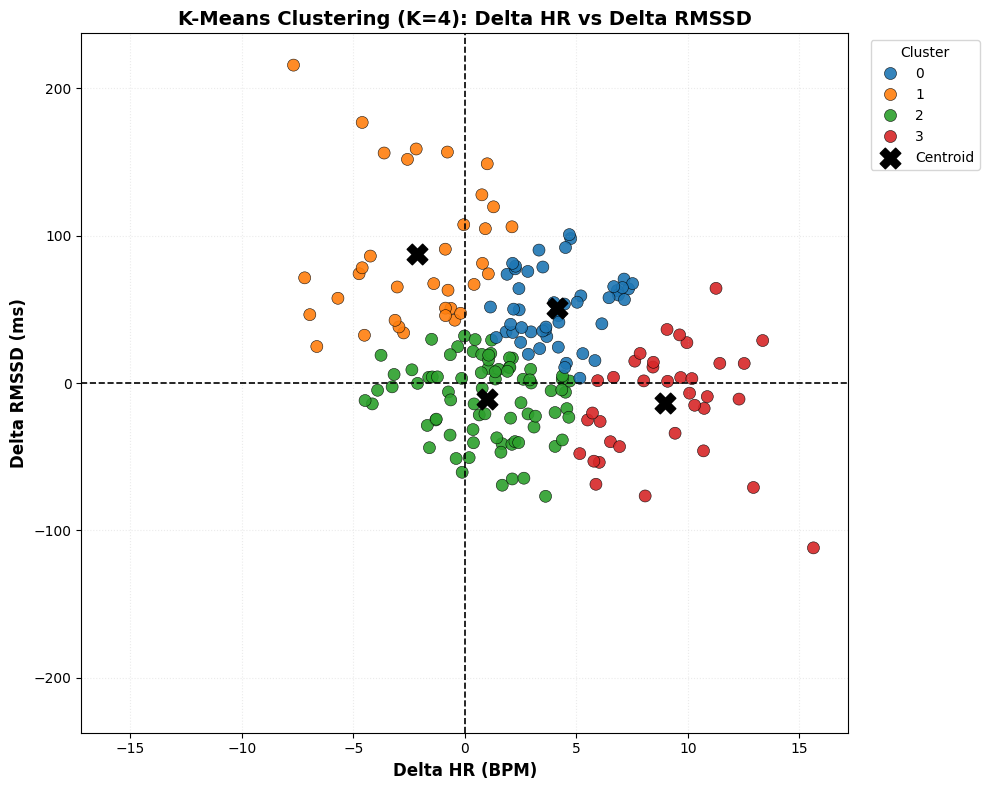

        Delta_HR               Delta_RMSSD                
           count   mean    std       count    mean     std
Cluster                                                   
0             50  4.128  1.783          50  50.792  23.629
1             35 -2.156  2.719          35  87.485  47.965
2             79  0.987  2.283          79 -10.945  26.261
3             36  8.996  2.587          36 -13.496  37.128


In [6]:
# K-Means 군집화 (Delta HR, Delta RMSSD)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

K = 4  # 필요하면 3, 5 등으로 변경

cluster_df = plot_df[['Subject', 'Task', 'Delta_HR', 'Delta_RMSSD']].copy()
X = cluster_df[['Delta_HR', 'Delta_RMSSD']].to_numpy()

# 축 단위가 달라 표준화 후 군집화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

# 중심점(표준화 공간 -> 원래 단위 복원)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=cluster_df,
    x='Delta_HR',
    y='Delta_RMSSD',
    hue='Cluster',
    palette='tab10',
    s=75,
    alpha=0.9,
    edgecolor='black',
    linewidth=0.4,
)

# 군집 중심 표시
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', s=220, marker='X',
    label='Centroid'
)

plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.axhline(0, color='black', linestyle='--', linewidth=1.2)

# 0 중심 대칭 축 유지
x_abs2 = max(abs(cluster_df['Delta_HR'].min()), abs(cluster_df['Delta_HR'].max()))
y_abs2 = max(abs(cluster_df['Delta_RMSSD'].min()), abs(cluster_df['Delta_RMSSD'].max()))
plt.xlim(-x_abs2 * 1.1, x_abs2 * 1.1)
plt.ylim(-y_abs2 * 1.1, y_abs2 * 1.1)

plt.title(f'K-Means Clustering (K={K}): Delta HR vs Delta RMSSD', fontsize=14, fontweight='bold')
plt.xlabel('Delta HR (BPM)', fontsize=12, fontweight='bold')
plt.ylabel('Delta RMSSD (ms)', fontsize=12, fontweight='bold')
plt.grid(alpha=0.25, linestyle=':')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 군집 요약 테이블
cluster_summary = (
    cluster_df.groupby('Cluster')[['Delta_HR', 'Delta_RMSSD']]
    .agg(['count', 'mean', 'std'])
    .round(3)
)
print(cluster_summary)

In [7]:
# Cluster x Task 교차 통계 (개수 + 클러스터 내 비율 %)
# cluster_df는 바로 위 K-Means 셀에서 생성됨

count_ct = pd.crosstab(cluster_df['Cluster'], cluster_df['Task'])
percent_ct = pd.crosstab(cluster_df['Cluster'], cluster_df['Task'], normalize='index') * 100

print('=== Cluster x Task Count Crosstab ===')
print(count_ct)

print('\n=== Cluster x Task Percentage Crosstab (row-normalized, %) ===')
print(percent_ct.round(2))

# 보기 좋게 하나의 테이블로 결합 (예: 12 (24.00%))
summary_table = count_ct.astype(str) + ' (' + percent_ct.round(2).astype(str) + '%)'
print('\n=== Combined Summary (Count + %) ===')
print(summary_table)

# 저장
count_path = Path('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/Only_BVP/cluster_task_crosstab_count.csv')
pct_path = Path('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/Only_BVP/cluster_task_crosstab_percent.csv')
count_ct.to_csv(count_path)
percent_ct.round(4).to_csv(pct_path)

print(f'\n저장 완료: {count_path}')
print(f'저장 완료: {pct_path}')

=== Cluster x Task Count Crosstab ===
Task     Logic  Nback  Stroop  Sudoku
Cluster                              
0           11      9      17      13
1            7      8      10      10
2           21     24      15      19
3           11      9       8       8

=== Cluster x Task Percentage Crosstab (row-normalized, %) ===
Task     Logic  Nback  Stroop  Sudoku
Cluster                              
0        22.00  18.00   34.00   26.00
1        20.00  22.86   28.57   28.57
2        26.58  30.38   18.99   24.05
3        30.56  25.00   22.22   22.22

=== Combined Summary (Count + %) ===
Task           Logic        Nback       Stroop       Sudoku
Cluster                                                    
0         11 (22.0%)    9 (18.0%)   17 (34.0%)   13 (26.0%)
1          7 (20.0%)   8 (22.86%)  10 (28.57%)  10 (28.57%)
2        21 (26.58%)  24 (30.38%)  15 (18.99%)  19 (24.05%)
3        11 (30.56%)    9 (25.0%)   8 (22.22%)   8 (22.22%)

저장 완료: /home/binghin2/Myproject/Research/CA

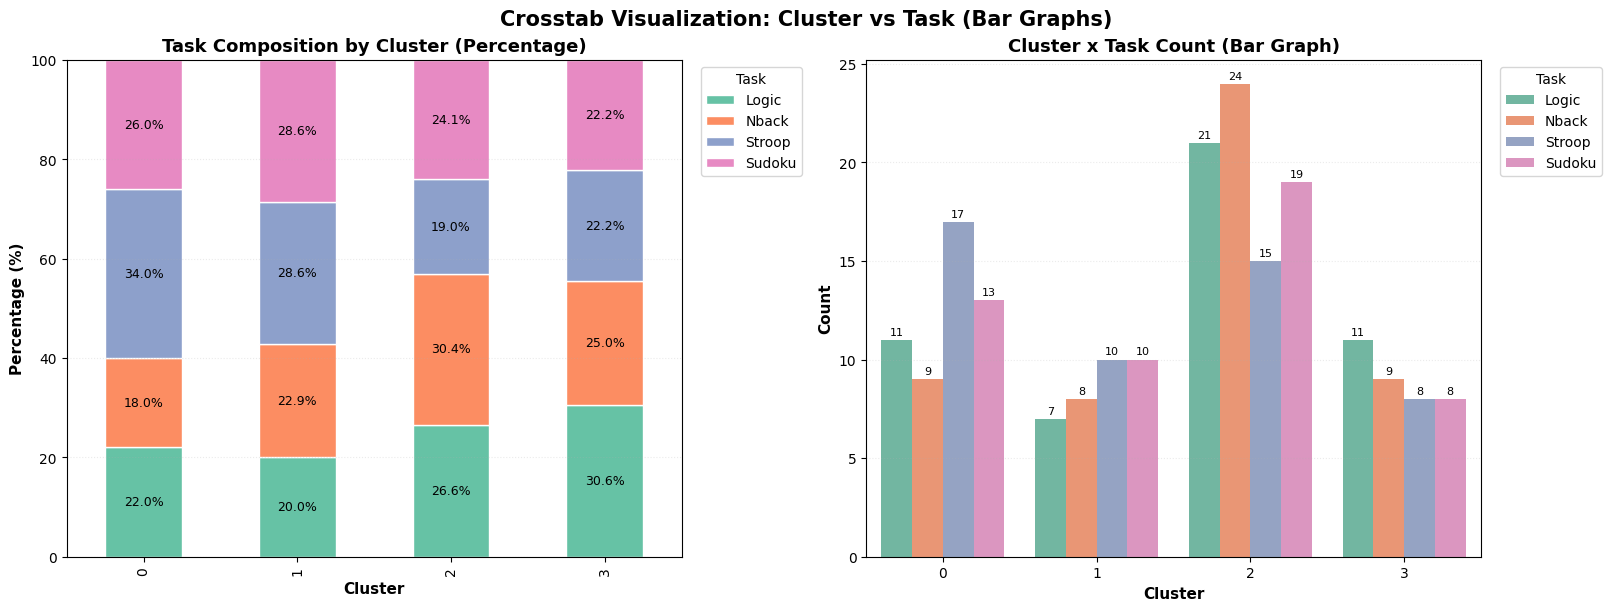

저장 완료: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Only_BVP/cluster_task_crosstab_bargraphs.png


In [9]:
# Cluster x Task 교차통계 시각화 (Bar Graph 버전)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# 1) 클러스터 내 Task 비율(%) 100% 누적 막대그래프
percent_plot = percent_ct.reindex(columns=['Logic', 'Nback', 'Stroop', 'Sudoku'])
percent_plot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=sns.color_palette('Set2', n_colors=4),
    edgecolor='white'
)
axes[0].set_title('Task Composition by Cluster (Percentage)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.25, linestyle=':')
axes[0].legend(title='Task', bbox_to_anchor=(1.02, 1), loc='upper left')

# 각 클러스터 막대 중앙에 주요 비율 라벨 표기(10% 이상만)
for container in axes[0].containers:
    labels = []
    for bar in container:
        h = bar.get_height()
        labels.append(f'{h:.1f}%' if h >= 10 else '')
    axes[0].bar_label(container, labels=labels, label_type='center', fontsize=9, color='black')

# 2) 개수 교차표 Grouped Bar Graph
count_plot = count_ct.reindex(columns=['Logic', 'Nback', 'Stroop', 'Sudoku'])
count_long = count_plot.reset_index().melt(id_vars='Cluster', var_name='Task', value_name='Count')

sns.barplot(
    data=count_long,
    x='Cluster',
    y='Count',
    hue='Task',
    hue_order=['Logic', 'Nback', 'Stroop', 'Sudoku'],
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Cluster x Task Count (Bar Graph)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.25, linestyle=':')
axes[1].legend(title='Task', bbox_to_anchor=(1.02, 1), loc='upper left')

# 오른쪽 막대 수치 라벨
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=2, fontsize=8)

plt.suptitle('Crosstab Visualization: Cluster vs Task (Bar Graphs)', fontsize=15, fontweight='bold')
plt.show()

# 저장
viz_path = Path('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/Only_BVP/cluster_task_crosstab_bargraphs.png')
fig.savefig(viz_path, dpi=250, bbox_inches='tight')
print(f'저장 완료: {viz_path}')